<a href="https://colab.research.google.com/github/zainazeem41472/Rice-Leaf-Disease-Classification/blob/main/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, Activation,
    Add, Input, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 7

BASE_DIR = "/content/drive/MyDrive/RiceLeafDiseases"

TRAIN_DIR = BASE_DIR + "/dataset_split/train"
VAL_DIR   = BASE_DIR + "/dataset_split/val"
TEST_DIR  = BASE_DIR + "/dataset_split/test"

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 4404 images belonging to 7 classes.
Found 940 images belonging to 7 classes.
Found 951 images belonging to 7 classes.
Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'irrelevant_pics', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


In [7]:
def residual_block(x, filters, stride=1):

    shortcut = x

    x = Conv2D(filters, (3,3), strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1,1), strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x

In [8]:
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = Conv2D(64, (7,7), strides=2, padding="same")(inputs)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling2D((3,3), strides=2, padding="same")(x)

# ResNet Blocks
x = residual_block(x, 64)
x = residual_block(x, 64)

x = residual_block(x, 128, stride=2)
x = residual_block(x, 128)

x = residual_block(x, 256, stride=2)
x = residual_block(x, 256)

x = residual_block(x, 512, stride=2)
x = residual_block(x, 512)

# Classification Head
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 11,459,207 (43.71 MB)

 Trainable params: 11,448,583 (43.67 MB)

 Non-trainable params: 10,624 (41.50 KB)

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1892s 14s/step - accuracy: 0.5766 - loss: 1.2466 - val_accuracy: 0.1404 - val_loss: 2.4868
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 73s 527ms/step - accuracy: 0.7297 - loss: 0.7726 - val_accuracy: 0.2436 - val_loss: 3.8994
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 73s 526ms/step - accuracy: 0.7780 - loss: 0.6397 - val_accuracy: 0.1649 - val_loss: 4.6252
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 73s 523ms/step - accuracy: 0.8095 - loss: 0.5769 - val_accuracy: 0.3596 - val_loss: 6.8386
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 72s 518ms/step - accuracy: 0.8109 - loss: 0.5196 - val_accuracy: 0.2436 - val_loss: 7.4853
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 72s 525ms/step - accuracy: 0.8434 - loss: 0.4369 - val_accuracy: 0.4372 - val_loss: 1.5033
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 72s 522ms/step - accuracy: 0.8576 - loss: 0.4166 - val_accuracy: 0.3426 - val_loss: 10.2979
Epoch 8/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 72s 522ms/step - accuracy: 0.8719 

In [14]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 346s 12s/step - accuracy: 0.2044 - loss: 6.8336
Test Accuracy: 0.24290220439434052


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

In [16]:
# Predict probabilities
predictions = model.predict(test_generator)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = test_generator.classes

30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 354ms/step


In [17]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.24290220820189273


In [18]:
print(classification_report(y_true, y_pred, target_names=class_names))

                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      0.09      0.16       141
           brown_spot       0.86      0.09      0.16       133
              healthy       1.00      0.09      0.17       131
      irrelevant_pics       0.18      1.00      0.30       150
           leaf_blast       0.75      0.34      0.47       133
           leaf_scald       0.00      0.00      0.00       131
    narrow_brown_spot       0.00      0.00      0.00       132

             accuracy                           0.24       951
            macro avg       0.54      0.23      0.18       951
         weighted avg       0.54      0.24      0.18       951



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 12   2   0 127   0   0   0]
 [  0  12   0 119   2   0   0]
 [  0   0  12 106  13   0   0]
 [  0   0   0 150   0   0   0]
 [  0   0   0  87  45   1   0]
 [  0   0   0 131   0   0   0]
 [  0   0   0 132   0   0   0]]


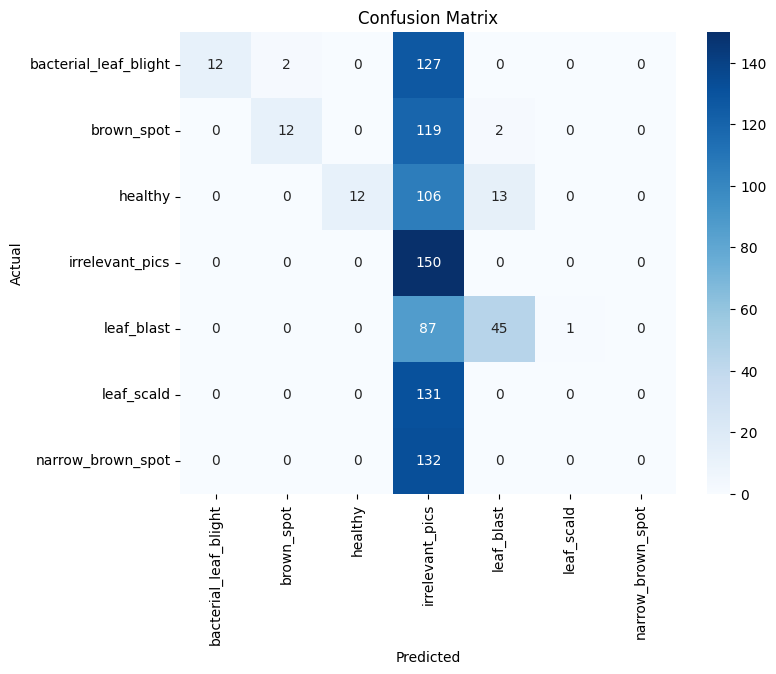

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.2044 - loss: 6.8336
Test Loss: 8.031450271606445
Test Accuracy: 0.24290220439434052


In [22]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step


In [23]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [25]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [26]:
TEST_DIR = "/content/drive/MyDrive/RiceLeafDiseases/dataset_split/test"

In [27]:
def test_random_images(model, test_dir, class_names, num_images=5):

    classes = os.listdir(test_dir)

    plt.figure(figsize=(15,6))

    for i in range(num_images):

        # pick random class
        class_name = random.choice(classes)

        # pick random image
        class_path = os.path.join(test_dir, class_name)
        img_name = random.choice(os.listdir(class_path))

        img_path = os.path.join(class_path, img_name)

        # load image
        img = image.load_img(img_path, target_size=(224,224))
        img_array = image.img_to_array(img)/255.0
        img_array = np.expand_dims(img_array, axis=0)

        # prediction
        prediction = model.predict(img_array, verbose=0)
        pred_class = class_names[np.argmax(prediction)]

        # plot
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(f"Actual: {class_name}\nPred: {pred_class}")
        plt.axis("off")

    plt.show()

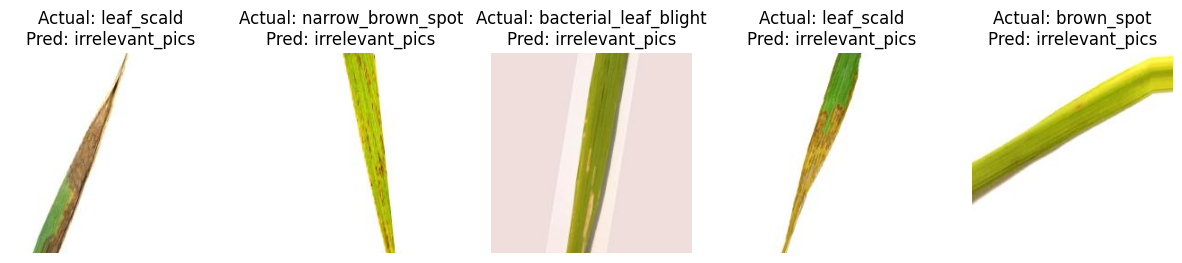

In [28]:
 test_random_images(model, TEST_DIR, class_names, num_images=5)